In [93]:
!pip -q install yfinance pandas matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

colours = sns.color_palette("muted")
sns.set_theme(style='whitegrid')



In [95]:
symbol = "AAPL"
start_data = "2015-01-01"
end_data = "2025-01-01"

starting_cash = 10000

In [96]:
# download raw data
raw_data = yf.download(symbol, start=start_data, end=end_data, auto_adjust=True)
# auto_adjust in case stock splits, so no artificial jumps.
"""A market may split e.g. 2 for 1, where 1 share becomes two shares, and the price per share halves.
This makes indivdual stock more affordable, improving liquidity."""

print(raw_data.head())

"""In the data below we see the date. Then the OHLC prices (per stock) that traders deal with. 
OPEN: price at which first trade occurs (when market opens.)
CLOSE: Last trade.
HIGH: highest price of the day.
LOW: lowest price of the day
VOLUME: total numer of shares traded."""

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400
2015-01-05  23.532719  24.064282  23.346673  23.984547  257142000
2015-01-06  23.534933  23.794069  23.173912  23.596948  263188400
2015-01-07  23.864946  23.964614  23.632387  23.743129  160423600
2015-01-08  24.781898  24.839485  24.075362  24.192751  237458000


'In the data below we see the date. Then the OHLC prices (per stock) that traders deal with. \nOPEN: price at which first trade occurs (when market opens.)\nCLOSE: Last trade.\nHIGH: highest price of the day.\nLOW: lowest price of the day\nVOLUME: total numer of shares traded.'

In [97]:
price = raw_data[["Close"]] # gets closing data
price = price.squeeze() # converts to single-column data frame into series w/ no title.
price = price.dropna()


In [98]:
daily_returns = price.pct_change() # price is closing data of each day. Calculates the percentage change between days.
daily_returns = daily_returns.fillna(0) # replace empties w/ 0.


In [99]:
buy_and_hold = pd.Series(1, index=price.index) # makes a series filled with 1s, with name dates.
#1 means to hold/buy every single day, always in the market. Most basic strategy, so used to compare other strategies.
#Effectively just never selling the stock. Watching what happens to the price.

momentum = (price.diff() > 0).astype(int) # if price goes up, then buy. If price.diff() between days is
#>0, then buy. astype(int) converts True/False to 1/0.

short_ma = price.rolling(20).mean() # buy when short-term avg > long term avg.
long_ma = price.rolling(50).mean() # rolling function makes a rolling window looking at last n days, taking average.
ma_cross = (short_ma > long_ma).astype(int) # this is the MAC method.

delta = price.diff()
gain = delta.clip(lower=0).rolling(14).mean() # if negative change, clip to 0. if positive keep.
loss = -delta.clip(upper=0).rolling(14).mean() # if positive clip to 0, if negative keep.
rsi = 100 - (100 / (1 + gain / loss)) # formula relative strength index RSI = 100 - 100 / (1 + RS)
# if RSI is near 100, mostly all gains recently, so overbought stock.
# if near 0, almost all losses recently, so oversold.
rsi_signal = (rsi < 30).astype(int) # buy when oversold.
#Remember buy low, sell high. Bets that the market overreacts when oversold, that price will snap back to true value afterwards. thus profit.
#Idea called mean reversion, idea that prices tend to drift back to long term avg.

ma = price.rolling(20).mean()
std = price.rolling(20).std()
lower_band = ma - 2 * std #lower band sits at 2std below mean (price below this is unusual/significant)
bb_signal = (price < lower_band).astype(int) # buy if drops below lower band, as it's cheap.



strategies = {
    "HOLD": buy_and_hold,
    "MOM": momentum,
    "Moving Average Crossover": ma_cross,
    "RSI": rsi_signal,
    "Bollinger Bands": bb_signal

}

In [100]:
def equity_curve(signal: pd.Series) -> pd.Series:
    shifted_signal = signal.shift(1).fillna(0) # 1 day later. Cannot use today's signal to trade today.
    # the signal is the 1/0 trade/don't boolean. Also fills any nans.

    daily_growth = 1 + shifted_signal * daily_returns # shifted signal (using whatever strategy) times returns
    # what growth u get if you use said method.
    # if signal 0 (out of market) 1 + 0 * return = 1.0, no change
    # if signal 1 (in market) 1 + 1 * return = ...
    # NB 1+ because of percentage change.

    return daily_growth.cumprod() * starting_cash # compound over time. Multiplies daily growth factors and original stock.

results = {} # dictionary that maps strategy name to equity curve. 

for name, signal in strategies.items(): # simulates every day through the strategies, giving results.
    results[name] = equity_curve(signal) # executes trade method.

print(f"Results for {symbol} from {start_data} to {end_data}:")

trading_years = len(price)/252

for name, curve in results.items():
    final_value = curve.iloc[-1] # gives final value, last place of cash posn.

    cagr = (final_value / starting_cash) ** (1 / trading_years) - 1 # just a formula. aggregate growth.
    # final = starting x rate ^ years. rearrange for rate.

    print(f"{name:<5}: | Final = ${final_value:,.0f} | CAGR = {cagr * 100} %")


Results for AAPL from 2015-01-01 to 2025-01-01:
HOLD : | Final = $102,854 | CAGR = 26.2940763325626 %
MOM  : | Final = $24,969 | CAGR = 9.598122215942983 %
Moving Average Crossover: | Final = $37,102 | CAGR = 14.033044932369766 %
RSI  : | Final = $14,614 | CAGR = 3.8729268545153017 %
Bollinger Bands: | Final = $12,646 | CAGR = 2.378881761427376 %


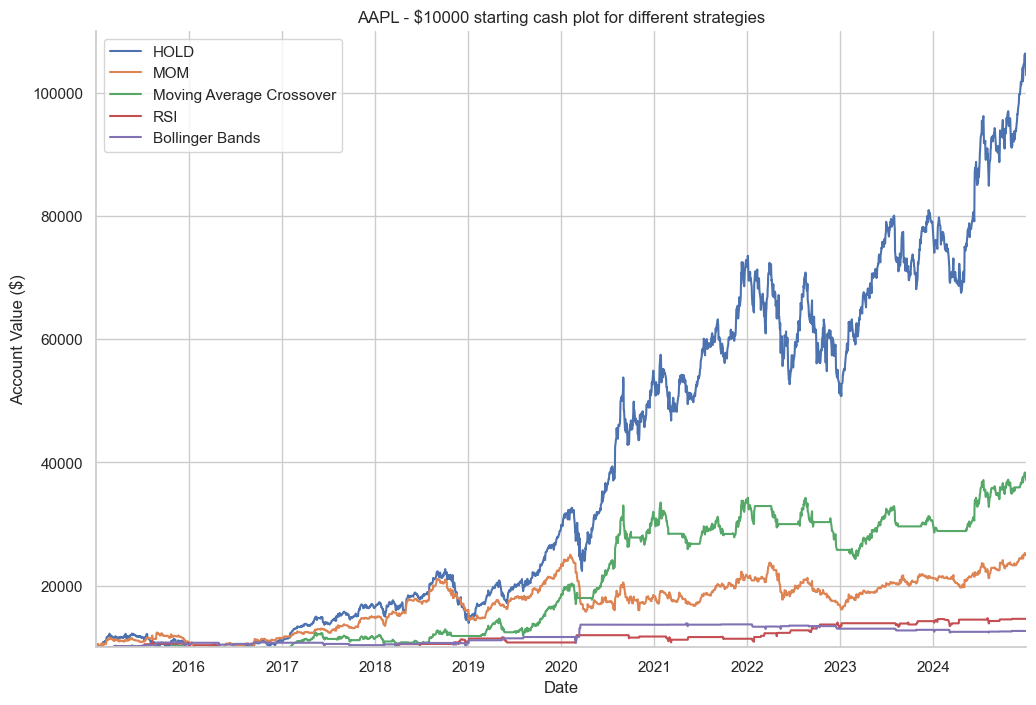

In [102]:
plt.figure(figsize=(12, 8))

for name, curve in results.items():
    plt.plot(curve, label=name)

plt.title(f'{symbol} - ${starting_cash} starting cash plot for different strategies')
plt.xlabel("Date")
plt.ylabel("Account Value ($)")
plt.xlim(curve.index[0], curve.index[-1])
plt.ylim(10000, 110000)
sns.despine()
plt.legend()
plt.grid(True)
plt.show()